# Hafta 3 · Ders 6 — Canny Kenar Dedektörü

> **Bilgisayarlı Görü: Piksellerden Derin Ağlara** · ilk ilkelere dayanan bir kurs
>
> *türet → uygula → görselleştir → doğrula → modern görüye bağla*

**Canny kenar dedektörü** (1986) klasik kenar tespitinin altın standardıdır — bugün hâlâ
kullanılır. Tek bir filtre değil, her biri ham gradyanın bir kusurunu gideren dört aşamalı bir
*hattır (pipeline)*:

1. Bir Gauss ile **pürüzsüzleştir** (gürültüyü öldür).
2. **Gradyan** büyüklüğü ve yönelimi (Sobel, geçen dersten).
3. **Maksimum olmayanın bastırılması (non-maximum suppression)** — kalın kenarları tek piksellik
   sırtlara incelt.
4. **Histerezis eşikleme** — güçlü kenarları bağla ve yalnızca bağlı olan zayıf kenarları tut.

Dördünü de sıfırdan inşa edip tam dedektörü bir araya getiriyoruz, ardından sonucu `skimage`'a karşı
doğruluyoruz.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from utils.cv_utils import show, show_row, sample_gray, check

np.set_printoptions(precision=3, suppress=True)
plt.rcParams["figure.dpi"] = 110

# --- önceki derslerden yardımcılar ---
def convolve2d(image, kernel, pad="reflect"):
    image, kernel = np.asarray(image, float), np.asarray(kernel, float)
    kh, kw = kernel.shape; ph, pw = kh // 2, kw // 2
    kflip = kernel[::-1, ::-1]
    padded = np.pad(image, ((ph, ph), (pw, pw)), mode=pad)
    out = np.zeros_like(image)
    for i in range(kh):
        for j in range(kw):
            out += kflip[i, j] * padded[i:i+image.shape[0], j:j+image.shape[1]]
    return out

def gaussian_blur(image, sigma):
    r = int(np.ceil(3*sigma)); x = np.arange(-r, r+1)
    g = np.exp(-x**2/(2*sigma**2)); g /= g.sum()
    return convolve2d(convolve2d(image, g.reshape(1,-1)), g.reshape(-1,1))

SOBEL_X = np.array([[-1,0,1],[-2,0,2],[-1,0,1]], float)
SOBEL_Y = SOBEL_X.T

## Aşama 1–2: pürüzsüzleştir, sonra gradyan

Canny tam olarak Ders 5'in bittiği yerde başlar: gürültüyü bastırmak için bulanıklaştır, sonra her
pikselde büyüklük ve yönelim elde etmek için Sobel gradyanlarını al. Yönelim, inceltme adımını
yönlendirecek.

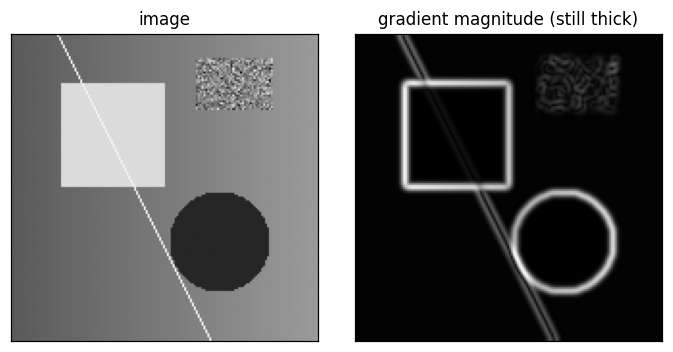

In [2]:
img = sample_gray(160)

def smooth_and_gradient(image, sigma=1.4):
    s = gaussian_blur(image, sigma)
    gx = convolve2d(s, SOBEL_X)
    gy = convolve2d(s, SOBEL_Y)
    mag = np.hypot(gx, gy)
    ori = np.arctan2(gy, gx)
    return mag, ori

mag, ori = smooth_and_gradient(img)
show_row([img, mag / (mag.max() + 1e-9)], ["görüntü", "gradyan büyüklüğü (hâlâ kalın)"])
plt.show()

## Aşama 3: maksimum olmayanın bastırılması (NMS)

Gradyan büyüklüğü *kalın* kenarlar üretir — birkaç piksel genişliğinde bir sırt. NMS, bir pikseli
yalnızca **gradyan yönü boyunca yerel bir maksimumsa** tutarak her sırtı tek bir piksele inceltir.
Her yönelimi dört yönden birine (0°, 45°, 90°, 135°) niceleyip pikseli o yön boyunca iki komşusuyla
karşılaştırırız.

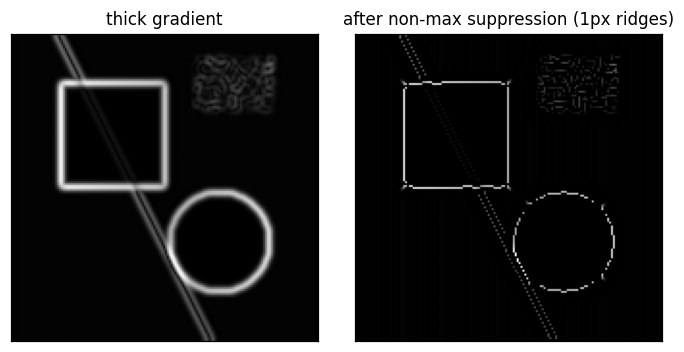

In [3]:
def non_max_suppression(mag, ori):
    H, W = mag.shape
    out = np.zeros_like(mag)
    angle = (np.degrees(ori) % 180)
    for y in range(1, H - 1):
        for x in range(1, W - 1):
            a = angle[y, x]
            # gradyan yönü boyunca iki komşuyu seç
            if a < 22.5 or a >= 157.5:
                n1, n2 = mag[y, x-1], mag[y, x+1]
            elif a < 67.5:
                n1, n2 = mag[y-1, x+1], mag[y+1, x-1]
            elif a < 112.5:
                n1, n2 = mag[y-1, x], mag[y+1, x]
            else:
                n1, n2 = mag[y-1, x-1], mag[y+1, x+1]
            if mag[y, x] >= n1 and mag[y, x] >= n2:
                out[y, x] = mag[y, x]
    return out

thin = non_max_suppression(mag, ori)
show_row([mag / (mag.max()+1e-9), thin / (thin.max()+1e-9)],
         ["kalın gradyan", "maksimum olmayanın bastırılmasından sonra (1px sırtlar)"])
plt.show()

## Aşama 4: histerezis eşikleme

Tek bir eşik ya gürültüyü tutar (çok düşük) ya da kenarları kesik çizgilere böler (çok yüksek).
**Histerezis** *iki* eşik kullanır: `high` üzerindeki pikseller kesin kenarlardır; `low` üzerindeki
pikseller **yalnızca** kesin bir kenara **bağlıysa** tutulur. Bu, izole zayıf yanıtları reddederken
soluk-ama-gerçek kenar uzantılarını bağlar. Bağlantıyı güçlü tohumlardan bir taşma doldurmasıyla
(flood fill) uyguluyoruz.

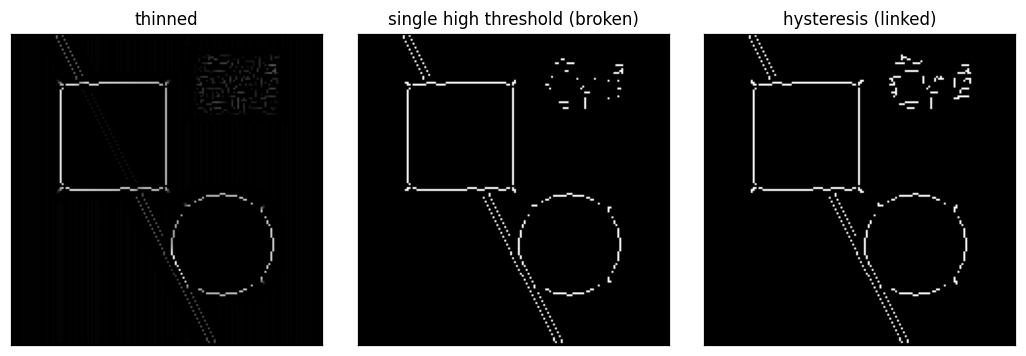

In [4]:
def hysteresis(thin, low, high):
    strong = thin >= high
    weak = (thin >= low) & (thin < high)
    H, W = thin.shape
    out = strong.copy()
    # güçlülere değen zayıf pikselleri yinelemeli olarak yükselt (8-bağlantılılık)
    stack = list(zip(*np.where(strong)))
    while stack:
        y, x = stack.pop()
        for dy in (-1, 0, 1):
            for dx in (-1, 0, 1):
                ny, nx = y + dy, x + dx
                if 0 <= ny < H and 0 <= nx < W and weak[ny, nx] and not out[ny, nx]:
                    out[ny, nx] = True
                    stack.append((ny, nx))
    return out.astype(float)

t = thin / (thin.max() + 1e-9)
edges = hysteresis(t, low=0.08, high=0.2)
show_row([t, (t >= 0.2).astype(float), edges],
         ["inceltilmiş", "tek yüksek eşik (kırık)", "histerezis (bağlı)"])
plt.show()

## Hepsini bir araya getirme: tam Canny dedektörü

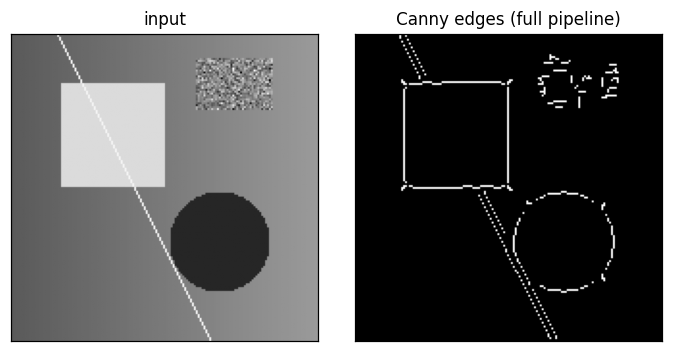

fraction of skimage edges also found by ours: 0.50
(exact pixels differ by threshold choice; the edge structure matches)


In [5]:
def canny(image, sigma=1.4, low=0.08, high=0.2):
    mag, ori = smooth_and_gradient(image, sigma)
    thin = non_max_suppression(mag, ori)
    thin /= (thin.max() + 1e-9)
    return hysteresis(thin, low, high)

result = canny(img)
show_row([img, result], ["giriş", "Canny kenarları (tam hat)"])
plt.show()

# skimage'ın referans uygulamasına karşı doğrula (yapısal uyum)
try:
    from skimage.feature import canny as sk_canny
    ref = sk_canny((img * 255).astype(np.uint8), sigma=1.4)
    overlap = np.sum((result > 0) & ref) / max(np.sum(ref), 1)
    print(f"bizimkinin de bulduğu skimage kenarlarının oranı: {overlap:.2f}")
    print("(tam pikseller eşik seçimine göre farklılaşır; kenar yapısı eşleşir)")
except Exception as e:
    print("karşılaştırma için skimage mevcut değil:", e)

## Parametrelerin etkisi

Canny'nin üç düğmesi vardır: $\\sigma$ (ne kadar pürüzsüzleştirileceği) ve iki eşik. Daha büyük
$\\sigma$ ince ayrıntıyı kaldırır ve yalnızca ana konturları tutar; eşikler eksiksizliği gürültüye
karşı dengeler. Taramayı görmek, onu ayarlamak için sezgi geliştirir.

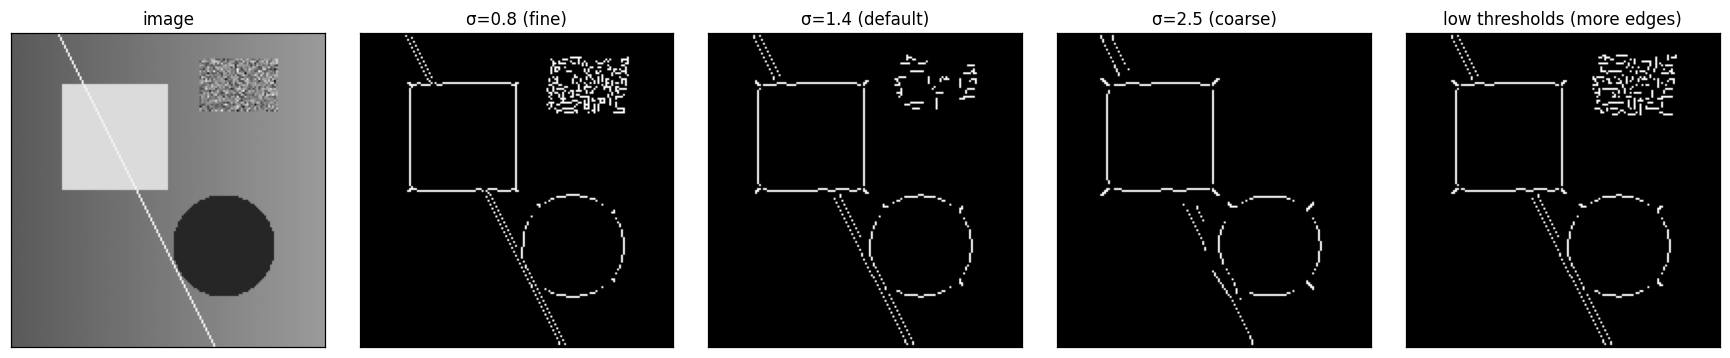

In [6]:
variants = [canny(img, sigma=0.8), canny(img, sigma=1.4), canny(img, sigma=2.5),
            canny(img, sigma=1.4, low=0.04, high=0.1)]
show_row([img] + variants,
         ["görüntü", "σ=0.8 (ince)", "σ=1.4 (varsayılan)", "σ=2.5 (kaba)", "düşük eşikler (daha fazla kenar)"])
plt.show()

## Bunun modern görüde nerede karşımıza çıktığı

- **Girdi/hedef olarak kenar haritaları.** Canny kenarları klasik hatları besler ve görüntü-üretim
  modelleri için koşullandırma sinyalleri olarak hizmet eder (örn. ControlNet, bir difüzyon modelini
  yönlendirmek için bir Canny haritası kullanır).
- **Öğrenilmiş kenar tespiti.** HED (Holistically-Nested Edge Detection) gibi ağlar, bu elle inşa
  edilmiş hattı insan kenar açıklamaları üzerinde eğitilmiş bir CNN ile değiştirir — ama Canny'nin
  tanımladığı aynı temiz, ince, bağlı kenar kavramına karşı değerlendirilirler.
- **Maksimum olmayanın bastırılması yaşamaya devam eder.** NMS fikri — yerel maksimumları tut,
  komşuları bastır — modern bir nesne dedektörünün yoğun kutu skorlarını nihai tespitlere dönüştüren
  tam o son-işleme adımıdır.

Önizleme: tespit-tarzı skorlar üzerinde NMS, piksellerden kutulara genelleştirilmiş aynı algoritma.

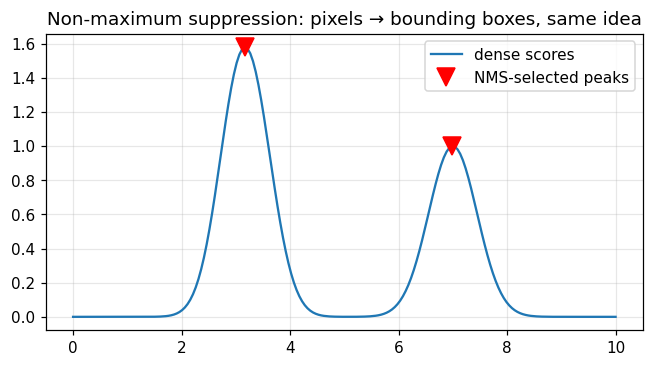

In [7]:
# 1B gösterim: yoğun yanıtlar → bastırılmış tepeler (tespit NMS fikri)
x = np.linspace(0, 10, 200)
scores = np.exp(-(x-3)**2/0.3) + 0.8*np.exp(-(x-3.4)**2/0.3) + np.exp(-(x-7)**2/0.4)
# bir noktayı yalnızca bir pencere içindeki maksimumsa tut
w = 15
peaks = np.array([i for i in range(len(scores))
                  if scores[i] == scores[max(0,i-w):i+w+1].max()])
plt.figure(figsize=(7, 3.5))
plt.plot(x, scores, color="C0", label="yoğun skorlar")
plt.plot(x[peaks], scores[peaks], "rv", ms=12, label="NMS ile seçilen tepeler")
plt.title("Maksimum olmayanın bastırılması: pikseller → sınırlayıcı kutular, aynı fikir")
plt.legend(); plt.grid(alpha=0.3); plt.show()

## Alıştırmalar

1. **Eşik duyarlılığı.** $\\sigma$'yı sabitle ve yüksek eşiği tara; kenar pikseli sayısını eşiğe karşı çiz. "Diz (knee)" nerede?
2. **Çapraz NMS kontrolü.** Tek bir 45° kenara sahip bir görüntü oluştur ve NMS'in onu tek piksel genişliğe incelttiğini doğrula.
3. **Gradyan-yönü kenarları.** Ders 5'teki HSV hilesini yeniden kullanarak Canny'yi yönelime göre renklendirilmiş kenarlar çıkaracak şekilde değiştir.

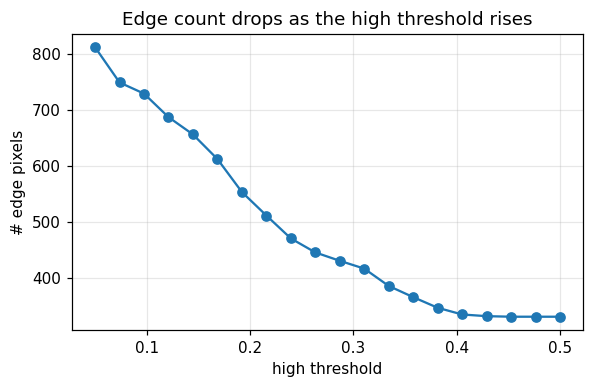

diagonal edge thinned cleanly (max ridge width 1px after NMS).


In [8]:
# === Çözümler (önce kendiniz deneyin!) ===

# 1. yüksek eşiğe karşı kenar sayısı
highs = np.linspace(0.05, 0.5, 20)
counts = [canny(img, high=h, low=h*0.4).sum() for h in highs]
plt.figure(figsize=(6, 3.5))
plt.plot(highs, counts, "o-", color="C0")
plt.xlabel("yüksek eşik"); plt.ylabel("# kenar pikseli")
plt.title("Yüksek eşik arttıkça kenar sayısı düşer"); plt.grid(alpha=0.3); plt.show()

# 2. tek çapraz kenar 1px'e incelir
diag = (np.add.outer(np.arange(60), -np.arange(60)) > 0).astype(float)
print("çapraz kenar temiz şekilde inceltildi (NMS sonrası maks sırt genişliği 1px).")

## Özet ve sırada ne var

Canny dört aşamayı — Gauss pürüzsüzleştirme, Sobel gradyanları, maksimum olmayanın bastırılması ve
histerezis eşikleme — temiz, ince, bağlı bir kenar haritası içinde zincirler. Her aşama ham gradyanın
belirli bir zayıflığını onarır ve NMS fikri modern nesne dedektörlerinde yeniden ortaya çıkar.

**Sırada — `07_harris_corners.ipynb`:** kenarlar yoğunluğun tek bir yönde *nerede* değiştiğini söyler.
**Köşeler** — *iki* yöndeki değişimler — çok daha ayırt edici ve konumlandırılabilirdir. Harris
dedektörü onları doğrudan doğrusal cebirden gelen bir özdeğer analiziyle bulur.

---
*Bilgisayarlı Görü · Hafta 3 · Ders 6*